# 03 · Calidad y drift con Evidently

Ejecutar todas las celdas en orden. Datos históricos y simulaciones educativas; no representan una aplicación financiera real.

In [1]:
from pathlib import Path
import sys, os
os.environ["EVIDENTLY_DO_NOT_TRACK"]="1"
base=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"_config.yml").exists())
project=base/"actividad_3/proyecto_inicial"
sys.path.insert(0,str(project/"src"))
os.environ["BANK_ROOT"]=str(project)
import numpy as np, pandas as pd
from bank_ops.data import load, partitions
from bank_ops.config import FEATURES, SEED
from bank_ops.model import pipeline, metrics
data=load(); train,validation,test=partitions(data)


In [2]:
from bank_ops.monitor import scenario, drift_report
pool=validation.sample(frac=1,random_state=SEED)
reference=pool.iloc[:1500].copy();current=pool.iloc[1500:3000].copy()
shifted=scenario(current,"shift")
report=drift_report(reference,shifted,"notebook")
print("Reporte en reports/drift_notebook.html")

Reporte en reports/drift_notebook.html


## Magnitud y contexto
Lotes independientes de una misma validación. Balance y canal cambian artificialmente.

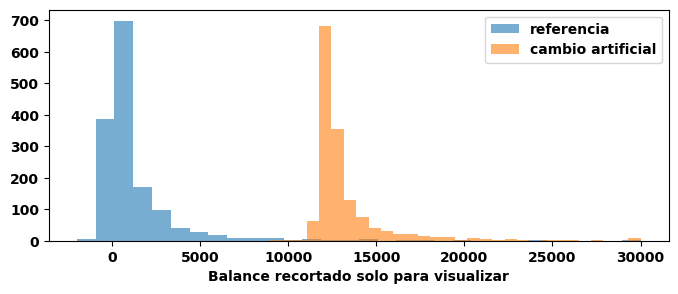

In [3]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(8,3))
ax.hist(reference.balance.clip(-2000,30000),bins=30,alpha=.6,label="referencia")
ax.hist(shifted.balance.clip(-2000,30000),bins=30,alpha=.6,label="cambio artificial")
ax.set_xlabel("Balance recortado solo para visualizar");ax.legend();plt.show()

In [4]:
from bank_ops.data import validate
try: validate(scenario(current,"invalid"))
except ValueError as error: print("Rechazo esperado:",error)
assert scenario(current,"degraded")[FEATURES].equals(current[FEATURES])

Rechazo esperado: campaign fuera del contrato


## Interpretación
Abrir HTML y revisar método, umbral, tamaño y columnas. ¿Por qué modificar etiquetas no es visible en las entradas? Proponer investigación antes de retraining.

## Profundización avanzada

Experimentos de estudio opcionales. No añaden entregables ni resuelven las tareas obligatorias del proyecto inicial.

### Hipótesis: la evidencia de cambio depende del volumen
Simulación reproducible con dos normales independientes y desplazamiento 0.10 en unidades de desviación estándar. Repetimos 30 veces por tamaño: la proporción de rechazos es una estimación exploratoria de sensibilidad en esta simulación, no una tasa garantizada para Bank Marketing. El experimento estable usa desplazamiento cero.

rechazos  distancia_media   D_medio
shift n                                        
0.0   200   0.033333         0.125557  0.087333
      800   0.066667         0.063381  0.042042
      3000  0.066667         0.030105  0.019911
0.1   200   0.333333         0.176428  0.109167
      800   0.333333         0.106566  0.060625
      3000  0.966667         0.105109  0.050244

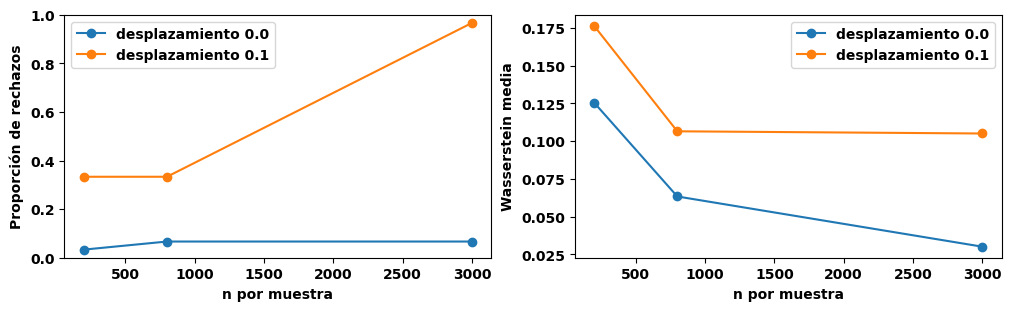

In [5]:
from scipy.stats import ks_2samp,wasserstein_distance
rng=np.random.default_rng(SEED)
rows=[]
for shift in [0,.1]:
    for n in [200,800,3000]:
        for repeat in range(30):
            a=rng.normal(size=n);b=rng.normal(loc=shift,size=n)
            test_ks=ks_2samp(a,b)
            rows.append({"shift":shift,"n":n,"D":test_ks.statistic,"p":test_ks.pvalue,
                         "W1":wasserstein_distance(a,b),"rechazo":test_ks.pvalue<.05})
simulation=pd.DataFrame(rows)
summary=simulation.groupby(["shift","n"]).agg(rechazos=("rechazo","mean"),distancia_media=("W1","mean"),D_medio=("D","mean"))
display(summary)
fig,axes=plt.subplots(1,2,figsize=(10,3),constrained_layout=True)
for shift,group in summary.reset_index().groupby("shift"):
    axes[0].plot(group.n,group.rechazos,marker="o",label=f"desplazamiento {shift}")
    axes[1].plot(group.n,group.distancia_media,marker="o",label=f"desplazamiento {shift}")
axes[0].set(xlabel="n por muestra",ylabel="Proporción de rechazos",ylim=(0,1))
axes[1].set(xlabel="n por muestra",ylabel="Wasserstein media")
for ax in axes:ax.legend()
plt.show()

**Interpretación:** la distancia empírica tiene variación de muestreo; no se exige que cada trayectoria sea monótona. Con 30 repeticiones la proporción de rechazos es ruidosa. El p-valor no expresa probabilidad de degradación. No trasladar el nivel 0.05 o el desplazamiento 0.10 a una política real sin estudiar sus consecuencias.

### PSI con intervalos fijados por la referencia
Usamos cuantiles de referencia, extremos infinitos para conservar masa y pseudoconteos de 0.5. Esta especificación es parte del resultado; cambiarla cambia PSI. No se usan umbrales universales de aceptación.

In [6]:
def psi_with_reference_bins(a,b,bins=10):
    inner=np.unique(np.quantile(a,np.linspace(0,1,bins+1)[1:-1]))
    edges=np.r_[-np.inf,inner,np.inf]
    count_a=np.histogram(a,bins=edges)[0].astype(float)+.5
    count_b=np.histogram(b,bins=edges)[0].astype(float)+.5
    p=count_a/count_a.sum();q=count_b/count_b.sum()
    return float(np.sum((q-p)*np.log(q/p)))
rows=[]
for bins in [5,10,20]:
    for delta in [0,1000,12000]:
        rows.append({"bins_solicitados":bins,"desplazamiento":delta,
                     "PSI":psi_with_reference_bins(reference.balance,current.balance+delta,bins)})
display(pd.DataFrame(rows))
assert abs(psi_with_reference_bins(reference.balance,reference.balance))<1e-12
assert scenario(current,"degraded")[FEATURES].equals(current[FEATURES])

,bins_solicitados,desplazamiento,PSI
0,5,0,0.005611
1,5,1000,2.332912
2,5,12000,6.394705
3,10,0,0.012561
4,10,1000,2.645923
5,10,12000,7.193388
6,20,0,0.018683
7,20,1000,2.657721
8,20,12000,7.578910


**Preguntas:** ¿cuánto cambia PSI al cambiar discretización?, ¿por qué se fijan intervalos con referencia?, ¿qué perdería un detector que solo mira features ante etiquetas invertidas? El reporte Evidently generado al comienzo usa su propia selección de métodos: estos experimentos explican familias de medidas, no sustituyen su configuración interna.